In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import genfromtxt
import os
import pickle
import seaborn as sns
import torch

from daart.data import DataGenerator
from daart.eval import get_precision_recall
from daart.io import get_expt_dir, find_experiment
from daart.models import Segmenter
from daart.transforms import ZScore

### define data paths

In [3]:
from daart_scratch.session_ids_fly import EXPT_IDS_TRAIN_5
expt_ids = EXPT_IDS_TRAIN_5[0]

base_dir = '/media/mattw/fly/behavior'

# get experiment dir
expt_dir = get_expt_dir(os.path.join(base_dir, 'classifiers'), expt_ids)
print(expt_dir)

/media/mattw/fly/behavior/classifiers/multi-0


### load model

In [6]:
model_type = 'gru'
tt_expt_dir = 'batch=2000_lr=1e-4'

device = 'cuda'
batch_size = 2000
trial_splits = '9;1;0;0'

hparams = {
    'rng_seed_train': 0,
    'rng_seed_model': 0,
    'trial_splits': trial_splits,
    'train_frac': 1,
    'model_type': model_type,
    'batch_size': batch_size,
    'learning_rate': 1e-4,
    'n_hid_layers': 2,
    'n_hid_units': 32,
    'n_lags': 4,
    'activation': 'lrelu',
    'l2_reg': 0,
    'device': device,
    'tt_expt_dir': os.path.join(expt_dir, model_type, tt_expt_dir),
    'bidirectional': True,
    'dropout': 0.1,
}

hparams['lambda_strong'] = 1
hparams['lambda_weak'] = 0.5
hparams['lambda_pred'] = 0.5
        
# load model
version_int = find_experiment(hparams)
version_str = str('version_%i' % version_int)
version_dir = os.path.join(hparams['tt_expt_dir'], version_str)
model_file = os.path.join(version_dir, 'best_val_model.pt')
arch_file = os.path.join(version_dir, 'hparams.pkl')
print('Loading model defined in %s' % arch_file)
with open(arch_file, 'rb') as f:
    hparams_new = pickle.load(f)
hparams_new['device'] = hparams.get('device', 'cpu')
model = Segmenter(hparams_new)
model.load_state_dict(torch.load(
    model_file, map_location=lambda storage, loc: storage))
model.to(hparams_new['device'])
model.eval()

Loading model defined in /media/mattw/fly/behavior/classifiers/multi-0/gru/batch=2000_lr=1e-4/version_10/hparams.pkl
computing predictions...done


In [8]:
import umap

expt_ids_test = [
    '2019_06_26_fly2',
#     '2019_08_14_fly1',
#     '2019_08_20_fly3',
#     '2019_10_14_fly2',
#     '2019_10_21_fly1',
]

for expt_id_test in expt_ids_test:

    # DLC markers
    markers_file = os.path.join(base_dir, 'markers', expt_id_test + '_labeled.h5')
    # hand labels
    hand_labels_file = os.path.join(
        base_dir, 'labels_deepethogram', 'DATA', expt_id_test, expt_id_test + '_labels.csv')
    # heuristic labels
    labels_file = os.path.join(
        base_dir, 'labels-heuristic', expt_id_test + '_labels.pkl')

    # define data generator signals
    signals = ['markers']
    transforms = [ZScore()]
    paths = [markers_file]

    # build data generator
    data_gen_test = DataGenerator(
        [expt_id_test], [signals], [transforms], [paths], device=device, batch_size=batch_size, 
        trial_splits=trial_splits)
    print(data_gen_test)

    # load hand labels
    labels = genfromtxt(hand_labels_file, delimiter=',', dtype=np.int, encoding=None)
    labels = labels[1:, 1:]  # get rid of headers, etc.
    states = np.argmax(labels, axis=1)
    cutoff = int(np.floor(states.shape[0] / batch_size)) * batch_size
    states = states[:cutoff]

    # load heuristic labels
    with open(labels_file, 'rb') as f:
        states_heuristic = pickle.load(f)['states']
        states_heuristic = states_heuristic[:cutoff]

    # compute predictions
    print('computing predictions...', end='')
    tmp = model.predict_labels(data_gen_test, return_scores=True)
    labels_pred = np.vstack(tmp['labels'][0])
    z = np.vstack(tmp['embedding'][0])
    # scores = np.vstack(tmp['scores'][0])
    print('done')

    # from sklearn.decomposition import PCA
    # pca = PCA(n_components=5)
    # zpca = pca.fit_transform(z)
    # print('pca done')

    # from sklearn.manifold import TSNE
    # tsne = TSNE(n_components=2)
    # zsne = tsne.fit_transform(scores)
    # print('t-sne done')

    umap_ = umap.UMAP(n_components=2, n_neighbors=500)
    zmap = umap_.fit_transform(z)
    print('umap done')

pca done
umap done


In [14]:
zmap.shape

(44000, 2)

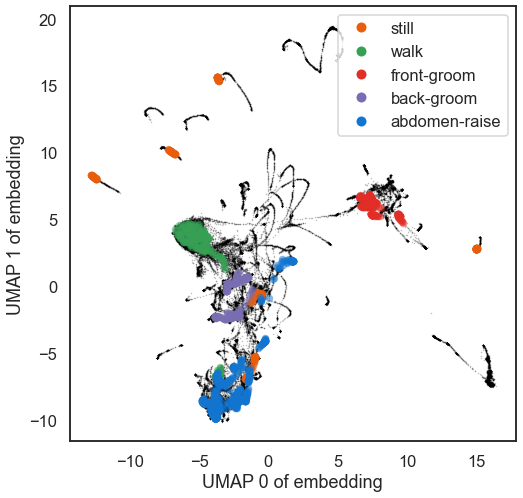

In [13]:
# predicted_class = np.argmax(predictions, axis=1)
idx0 = 0
idx1 = 1
color_by = 'hand'
# color_by = 'heuristic'

# plot_dims = 'pca'
plot_dims = 'umap'
# plot_dims = 'scores'
# plot_dims = 'tsne'

# prop_cycle = plt.rcParams['axes.prop_cycle']
# colors = prop_cycle.by_key()['color']
colors = [
    (1, 1, 1, 1),
    (233 / 255, 94 / 255, 13 / 255, 1),
    (55 / 255, 160 / 255, 85 / 255, 1),
    (226 / 255, 46 / 255, 39 / 255, 1),
    (121 / 255, 110 / 255, 178 / 255, 1),
    (18 / 255, 117 / 255, 207 / 255, 1),
]

if plot_dims == 'pca':
    pts = zpca
    label_str = 'PC'
elif plot_dims == 'scores':
    pts = scores
    label_str = 'Score'
elif plot_dims == 'tsne':
    pts = zsne
    label_str = 'TSNE'
elif plot_dims == 'umap':
    pts = zmap
    label_str = 'UMAP'

plt.figure(figsize=(8, 8))
plt.plot(pts[:, idx0], pts[:, idx1], '.k', markersize=1, alpha=0.25)
for l_idx, l in enumerate(label_names):
    if l == 'background': 
        continue
    if color_by == 'hand':
        idxs = np.where(states == l_idx)[0]
        markersize = 15
        alpha = 0.5
    else:
        idxs = np.where(states_heuristic == l_idx)[0]
        markersize = 10
        alpha = 0.05
    plt.plot(
        pts[idxs, idx0], pts[idxs, idx1], '.', markersize=markersize, alpha=alpha,
        markerfacecolor=colors[l_idx], markeredgecolor=colors[l_idx],
        markeredgewidth=0, label=l)
plt.xlabel('%s %i of embedding' % (label_str, idx0))
plt.ylabel('%s %i of embedding' % (label_str, idx1))
# plt.legend()
def update_prop(handle, orig):
    handle.update_from(orig)
    handle.set_alpha(1)
    handle.set_markersize(20)

from matplotlib.legend_handler import HandlerLine2D
plt.legend(handler_map={plt.Line2D:HandlerLine2D(update_func=update_prop)})
plt.savefig(
    '/home/mattw/Dropbox/research-text/papers/2021-daart/figs/abdomen-raise/%s_wlables.pdf' %
    expt_id_test)
plt.show()